In [1]:
import torch
import torch.nn as nn
import numpy as np
import random

from kan import KAN
from kan.utils import create_dataset

import wandb
# import torch.profiler
# import fvcore
import time


import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device, torch.__version__)

cuda 2.2.2+cu121


In [2]:
# Define target function from KAN paper
def target_func(x):
    return torch.exp(torch.sin(torch.pi * x[:,0]) + x[:, 1]**2)
def count_parameters(model):
    """Count trainable parameters in a PyTorch model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [3]:
# Create dataset
n_var = 2
ranges = [-1, 1]
train_num: int = 10000
test_num: int = 10000
dataset = create_dataset(target_func, n_var=n_var, ranges=ranges, train_num=train_num, test_num=test_num, device=device)

In [18]:
import random
import wandb

# Initialize W&B project
wandb.init(
    entity="hpml_project_spring25",
    project="MPKAN-Results",
    config={
    "seed": random.randint(0, 200),
    "grid_size": 5,
    "epochs": 100,
    "lr": 0.01,
    # "batch_size": 256,
    "equation": "exp(sin(\pi x) + x**2)",
    "n_var": n_var,
    "ranges": ranges,
    "train_num": train_num,
    "test_num": test_num,
    "input_dim": n_var,
    "kan_hidden_dim": 5,
    "output_dim": 1,
    "spline_order":3, 
})

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇██
kan_train_loss,█▇▄▁
kan_train_time_per_epoch_sec,▅▁▁▅▃▄▃▃▃▃▃▃▃▃▄▃▃▃▃▃▄▄▄▄▅▅▄▅▅▄▆▅▅▅▅▅█▇▇▇
kan_trainable_params,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
kan_val_loss,█▆▃▂▁
kan_val_rmse,█▆▄▃▁
mlp_train_loss,█▆▄▃▁
mlp_train_time_per_epoch_sec,▄▅▄▃▁▅▄▄▃▅▃▄▃▄▄▃▃▄▃▄▅▅▄▆▅▄▅▅▅▆▅▅▅▆▆▆████
mlp_trainable_params,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇████
mlp_val_loss,█▇▅▄▁
mlp_val_rmse,█▃▁


In [19]:
from kan import *
#torch.set_default_dtype(torch.double)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
kan_model = KAN(width=[wandb.config.input_dim, wandb.config.kan_hidden_dim, wandb.config.output_dim], 
    grid=wandb.config.grid_size, 
    k=wandb.config.spline_order, 
    seed=wandb.config.seed, 
    device=device)
mpkan_model = MPKAN(width=[wandb.config.input_dim, wandb.config.kan_hidden_dim, wandb.config.output_dim], 
    grid=wandb.config.grid_size, 
    k=wandb.config.spline_order, 
    seed=wandb.config.seed, 
    device=device)

cuda
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0


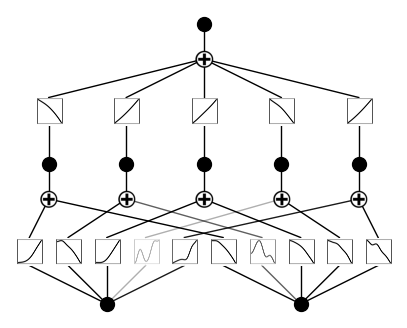

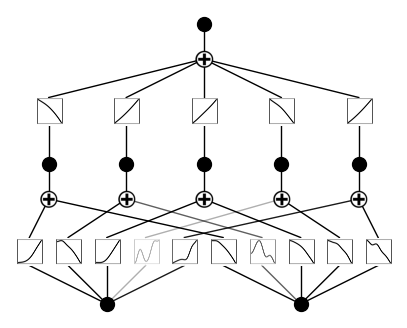

In [20]:
# plot KAN at initialization
kan_model(dataset['train_input']);
kan_model.plot()

# plot MPKAN at initialization
mpkan_model(dataset['train_input']);
mpkan_model.plot()

In [21]:
kan_params = count_parameters(kan_model)
mpkan_params = count_parameters(mpkan_model)
wandb.config.kan_params = kan_params
wandb.config.mpkan_params = mpkan_params

In [22]:
wandb.watch((kan_model, mpkan_model), log="all")

# Loss and optimizers
criterion = torch.nn.MSELoss()
kan_optim = torch.optim.Adam(kan_model.parameters(), lr=wandb.config.lr)
mpkan_optim = torch.optim.Adam(mpkan_model.parameters(), lr=wandb.config.lr)

grid_size = wandb.config.grid_size 


In [24]:
# train for 100 epochs
for epoch in range(wandb.config.epochs):
    kan_model.train()
    mpkan_model.train()
    
    # KAN training
    kan_optim.zero_grad()
    torch.cuda.synchronize()
    start_time = time.perf_counter()
    result = kan_model.fit(dataset, opt="Adam", steps=50)
    kan_loss = result['train_loss']
    # kan_pred = kan_model(dataset['train_input'])
    # kan_loss = criterion(kan_pred, dataset['train_label'])
    # kan_loss.backward()
    torch.cuda.synchronize()
    duration_kan = (time.perf_counter() - start_time)
    # kan_optim.step()
    
    
    # MPKAN training
    mpkan_optim.zero_grad()
    torch.cuda.synchronize()
    start_time = time.perf_counter()
    result = mpkan_model.fit(dataset, opt="Adam", steps=50)
    mpkan_loss = torch.mean(torch.square(result['train_loss']))
    # mpkan_loss.backward()
    torch.cuda.synchronize()
    duration_mpkan = (time.perf_counter() - start_time)
    # mpkan_optim.step()
    
    with torch.no_grad():
        kan_model.eval()
        mpkan_model.eval()
        
        kan_val = criterion(kan_model(dataset['test_input']), dataset['test_label'])
        mpkan_val = criterion(mpkan_model(dataset['test_input']), dataset['test_label'])

    # Log metrics
    wandb.log({
        "epoch": epoch,
        "kan_train_loss": kan_loss.item(),
        "mpkan_train_loss": mpkan_loss.item(),
        "kan_val_loss": kan_val.item(),
        "mpkan_val_loss": mpkan_val.item(),
        "kan_val_rmse": torch.sqrt(kan_val).item(),
        "mpkan_val_rmse": torch.sqrt(mpkan_val).item(),
        "kan_trainable_params": count_parameters(kan_model),
        "mpkan_trainable_params": count_parameters(mpkan_model),
        # "kan_flops": flop_kan,
        # "mpkan_flops": flop_mpkan,
        # "kan_flops_per_sec": flops_per_sec_kan,
        # "mpkan_flops_per_sec": flops_per_sec_mpkan,
        "kan_train_time_per_epoch_sec": duration_kan,
        "mpkan_train_time_per_epoch_sec": duration_mpkan,
    })

    if (epoch + 1) % 10 == 0:
        wandb.config.grid_size += 5
        kan_model = kan_model.refine(wandb.config.grid_size)
        kan_optim = torch.optim.Adam(kan_model.parameters(), lr=wandb.config.lr)

        mpkan_model = mpkan_model.refine(wandb.config.grid_size)
        mpkan_optim = torch.optim.Adam(mpkan_model.parameters(), lr=wandb.config.lr)

# Final evaluation
with torch.no_grad():
    kan_model.eval()
    mpkan_model.eval()
    

    grid_plot_size = 100
    # Generate predictions
    x = torch.linspace(wandb.config.ranges[0], wandb.config.ranges[1], grid_plot_size)
    X, Y = torch.meshgrid(x, x, indexing='ij')
    grid_input = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)

    Z = target_func(grid_input).reshape(grid_plot_size, grid_plot_size)
    kan_pred = kan_model(grid_input).cpu().reshape(grid_plot_size, grid_plot_size)
    mpkan_pred = mpkan_model(grid_input).cpu().reshape(grid_plot_size, grid_plot_size)

    fig = plt.figure(figsize=(16, 9))
    ax = fig.add_subplot(111, projection='3d')
    # Plot surfaces
    ax.plot_surface(X.cpu().numpy(), Y.cpu().numpy(), Z.cpu().numpy(), alpha=0.5, color='cyan')
    ax.plot_surface(X.cpu().numpy(), Y.cpu().numpy(), kan_pred.cpu().numpy(), alpha=0.5, color='magenta')
    ax.plot_surface(X.cpu().numpy(), Y.cpu().numpy(), mpkan_pred.cpu().numpy(), alpha=0.5, color='yellow')

    # Create proxy artists for legend
    # legend_proxies = [
    #     Line2D([0], [0], marker='s', linestyle='none', markersize=10, 
    #         markerfacecolor='cyan', alpha=0.5, label='True'),
    #     Line2D([0], [0], marker='s', linestyle='none', markersize=10, 
    #         markerfacecolor='magenta', alpha=0.5, label='KAN'),
    #     Line2D([0], [0], marker='s', linestyle='none', markersize=10, 
    #         markerfacecolor='yellow', alpha=0.5, label='MixedKAN')
    # ]

    ax.set_xlabel('Input X')
    ax.set_ylabel('Input Y')
    ax.set_zlabel('Label Z')
    #ax.legend(handles=legend_proxies)
    wandb.log({"predictions": wandb.Image(fig)})
    plt.close()

# Parametric complexity analysis
wandb.log({
    "kan_vs_mpkan_complexity": wandb.plot.line_series(
        xs=[wandb.config.epochs, wandb.config.epochs],
        ys=[[sum(p.numel() for p in kan_model.parameters())], 
            [sum(p.numel() for p in mpkan_model.parameters())]],
        title="Model Complexity",
        xname="Epochs",
        keys=["KAN", "MixedKAN"]
    )
})

wandb.finish()


| train_loss: nan | test_loss: nan | reg: nan | : 100%|█████████████| 50/50 [00:01<00:00, 35.89it/s]


saving model version 0.11


| train_loss: nan | test_loss: nan | reg: nan | : 100%|█████████████| 50/50 [00:01<00:00, 37.71it/s]


saving model version 0.12


AttributeError: 'list' object has no attribute 'item'